In [32]:
import spacy
import nltk

In [33]:
# Baixar os recursos do NLTK necessários
try:
    nltk.data.find('tokenizers/punkt_tab')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('stemmers/rslp')
except LookupError:
    nltk.download('punkt_tab')
    nltk.download('stopwords')
    nltk.download('rslp')

In [34]:
# Baixar o modelo de linguagem do spaCy para português
try:
    nlp = spacy.load("pt_core_news_sm")
    print("Modelo de linguagem do spaCy carregado com sucesso!")
except OSError:
    print('Execute o seguinte comando: python -m spacy download pt_core_news_sm')

Modelo de linguagem do spaCy carregado com sucesso!


In [35]:
# Texto com ruidos: Pontuação, Case variado, Dados sensíveis, Formatação um pouco inconsistente
texto_bruto ="""
    URGENTE: O Cientista de Dados (Senior) enviou um e-mail para rh@empresa.com.br!!!
    O salário proposto é de R$ 12.500,00.
    O CPF do candidato é 123.456.789-00 e ele domina: Python, NLP e REGEX.
    OBS: Nós amamos processamento de linguagem natural...
    """
print("Texto bruto:\n", texto_bruto)


Texto bruto:
 
    URGENTE: O Cientista de Dados (Senior) enviou um e-mail para rh@empresa.com.br!!!
    O salário proposto é de R$ 12.500,00.
    O CPF do candidato é 123.456.789-00 e ele domina: Python, NLP e REGEX.
    OBS: Nós amamos processamento de linguagem natural...
    


### Tokenização

In [36]:
# Abordagem mais ingênua (ruim para NLP)
tokens_split = texto_bruto.split()
print("\nTokens (split):\n", tokens_split[:10]) # Exibindo apenas os 10 primeiros tokens para não poluir a saída


Tokens (split):
 ['URGENTE:', 'O', 'Cientista', 'de', 'Dados', '(Senior)', 'enviou', 'um', 'e-mail', 'para']


In [37]:
# Abordagem NLTK (separando a pontuação das palavras)
tokens_nltk = nltk.word_tokenize(texto_bruto, language='portuguese') # Tokenização usando NLTK
print("\nTokens (NLTK):\n", tokens_nltk[:10]) # Exibindo apenas os 10 primeiros tokens para não poluir a saída



Tokens (NLTK):
 ['URGENTE', ':', 'O', 'Cientista', 'de', 'Dados', '(', 'Senior', ')', 'enviou']


In [38]:
# Abordagem com SpaCy (separando a pontuação das palavras e mantendo a estrutura do texto)
doc = nlp(texto_bruto) # Tokenização usando SpaCy
tokens_spacy = [token.text for token in doc]
print("\nTokens (SpaCy):\n", tokens_spacy[:10]) # Exibindo apenas os 10 primeiros tokens para não poluir a saída


Tokens (SpaCy):
 ['\n    ', 'URGENTE', ':', 'O', 'Cientista', 'de', 'Dados', '(', 'Senior', ')']


In [39]:
# Abordagem com NLTK (Tab)
tab_tokens = nltk.tokenize.TabTokenizer().tokenize(texto_bruto)
print("\nTokens (Tab):\n", tab_tokens) # Exibindo apenas os 10 primeiros tokens para não poluir a saída


Tokens (Tab):
 ['\n    URGENTE: O Cientista de Dados (Senior) enviou um e-mail para rh@empresa.com.br!!!\n    O salário proposto é de R$ 12.500,00.\n    O CPF do candidato é 123.456.789-00 e ele domina: Python, NLP e REGEX.\n    OBS: Nós amamos processamento de linguagem natural...\n    ']


In [40]:
# Abordagem NLTK (Line)
line_tokens = nltk.tokenize.line_tokenize(texto_bruto)
print("\nTokens (Line):\n", line_tokens[:10]) # Exibindo apenas os 10 primeiros tokens para não poluir a saída


Tokens (Line):
 ['    URGENTE: O Cientista de Dados (Senior) enviou um e-mail para rh@empresa.com.br!!!', '    O salário proposto é de R$ 12.500,00.', '    O CPF do candidato é 123.456.789-00 e ele domina: Python, NLP e REGEX.', '    OBS: Nós amamos processamento de linguagem natural...']


In [41]:
# Aboradagem Char Tokenizer
char_tokens = [char for char in texto_bruto]
print("\nTokens (Char):\n", char_tokens[:30]) # Exibindo apenas os 10 primeiros tokens para não poluir a saída


Tokens (Char):
 ['\n', ' ', ' ', ' ', ' ', 'U', 'R', 'G', 'E', 'N', 'T', 'E', ':', ' ', 'O', ' ', 'C', 'i', 'e', 'n', 't', 'i', 's', 't', 'a', ' ', 'd', 'e', ' ', 'D']


### Normalização de Texto

In [42]:
# Normalizar o texto segundo o Case
texto_lower = texto_bruto.lower()
print("\nTexto normalizado (lower):\n", texto_lower)


Texto normalizado (lower):
 
    urgente: o cientista de dados (senior) enviou um e-mail para rh@empresa.com.br!!!
    o salário proposto é de r$ 12.500,00.
    o cpf do candidato é 123.456.789-00 e ele domina: python, nlp e regex.
    obs: nós amamos processamento de linguagem natural...
    


In [43]:
# Normalizar removendo a pontuação do texto
pontuacao = """!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""
texto_sem_pontuacao = ''.join(char for char in texto_bruto if char not in pontuacao)
print("\nTexto normalizado (sem pontuação):\n", texto_sem_pontuacao)


Texto normalizado (sem pontuação):
 
    URGENTE O Cientista de Dados Senior enviou um email para rhempresacombr
    O salário proposto é de R 1250000
    O CPF do candidato é 12345678900 e ele domina Python NLP e REGEX
    OBS Nós amamos processamento de linguagem natural
    


<>:2: SyntaxWarning: invalid escape sequence '\]'
<>:2: SyntaxWarning: invalid escape sequence '\]'
C:\Users\ricardo.ribeiro\AppData\Local\Temp\ipykernel_14468\2790902847.py:2: SyntaxWarning: invalid escape sequence '\]'
  pontuacao = """!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""


In [44]:
# Remover acentos do texto
import unicodedata
texto_sem_acentos = ''.join(c for c in unicodedata.normalize('NFD', texto_bruto) if unicodedata.category(c) != 'Mn')
print("\nTexto normalizado (sem acentos):\n", texto_sem_acentos)


Texto normalizado (sem acentos):
 
    URGENTE: O Cientista de Dados (Senior) enviou um e-mail para rh@empresa.com.br!!!
    O salario proposto e de R$ 12.500,00.
    O CPF do candidato e 123.456.789-00 e ele domina: Python, NLP e REGEX.
    OBS: Nos amamos processamento de linguagem natural...
    


### Stop-Words e Pontuação

In [45]:
# Carregar lista de stopwords em português do NLTK
stop_words_pt = set(nltk.corpus.stopwords.words('portuguese'))
len(stop_words_pt) # Exibindo a quantidade de stopwords em português
# print("\nStopwords em português (NLTK):\n", list(stop_words_pt)[:10]) # Exibindo apenas as 10 primeiras stopwords para não poluir a saída

#Filtragem de stop workds e somente alfanumericas
tokens_filtrados = [
    token for token in tokens_nltk
    if token.isalnum() and token.lower() not in stop_words_pt
]

print(tokens_filtrados) # Exibindo apenas os 10 primeiros tokens para não poluir a saída

['URGENTE', 'Cientista', 'Dados', 'Senior', 'enviou', 'rh', 'salário', 'proposto', 'R', 'CPF', 'candidato', 'domina', 'Python', 'NLP', 'REGEX', 'OBS', 'amamos', 'processamento', 'linguagem', 'natural']


### Lemmatização

In [ ]:
for token in doc:
    if token.is_punct or token.is_space:
        continue

    word = token.text
    lemma = token.lemma_
    pos = token.pos_
    print(f"Token: {word}, Lemma: {lemma}, POS: {pos}")

Token: URGENTE, Lemma: URGENTE, POS: NOUN
Token: O, Lemma: o, POS: DET
Token: Cientista, Lemma: Cientista, POS: PROPN
Token: de, Lemma: de, POS: ADP
Token: Dados, Lemma: Dados, POS: PROPN
Token: Senior, Lemma: Senior, POS: PROPN
Token: enviou, Lemma: enviar, POS: VERB
Token: um, Lemma: um, POS: DET
Token: e-mail, Lemma: e-mail, POS: NOUN
Token: para, Lemma: para, POS: ADP
Token: rh@empresa.com.br, Lemma: rh@empresa.com.br, POS: NOUN
Token: O, Lemma: o, POS: DET
Token: salário, Lemma: salário, POS: NOUN
Token: proposto, Lemma: propor, POS: VERB
Token: é, Lemma: ser, POS: AUX
Token: de, Lemma: de, POS: ADP
Token: R$, Lemma: R$, POS: SYM
Token: 12.500,00, Lemma: 12.500,00, POS: NUM
Token: O, Lemma: o, POS: DET
Token: CPF, Lemma: CPF, POS: NOUN
Token: do, Lemma: de o, POS: ADP
Token: candidato, Lemma: candidato, POS: NOUN
Token: é, Lemma: ser, POS: AUX
Token: 123.456., Lemma: 123.456., POS: ADJ
Token: 789-00, Lemma: 789-00, POS: NUM
Token: e, Lemma: e, POS: CCONJ
Token: ele, Lemma: ele, PO

### Laboratório RegEx

In [4]:
import re # Biblioteca para expressões regulares

In [6]:
# Função auxiliar para destacar o resultado do RegEX

def mostrar_match(padrao, texto, descricao):
    print(f"--- {descricao} ---")
    print(f"Padrão: '{padrao}' | Texto: '{texto}'")
    encontrados = re.findall(padrao, texto)
    print(f"Resultado: {encontrados}\n")

### Metacaracteres, Class Personalizadas e Qualificadores

In [ ]:
texto_exemplo = "O agente 007 ligou às 14h. O código informado foi aeiou_123"

mostrar_match(r'\d', texto_exemplo, "Digitos individuais (\\d)") # Dígitos individuais

--- Digitos individuais (\d) ---
Padrão: '\d' | Texto: 'O agente 007 ligou às 14h. O código informado foi aeiou_123'
Resultado: ['0', '0', '7', '1', '4', '1', '2', '3']



In [ ]:
mostrar_match(r'\w', texto_exemplo, "Alfanuméricos individuais (\\w)") # trei os pontos do texto

--- Alfanuméricos individuais (\w) ---
Padrão: '\w' | Texto: 'O agente 007 ligou às 14h. O código informado foi aeiou_123'
Resultado: ['O', 'a', 'g', 'e', 'n', 't', 'e', '0', '0', '7', 'l', 'i', 'g', 'o', 'u', 'à', 's', '1', '4', 'h', 'O', 'c', 'ó', 'd', 'i', 'g', 'o', 'i', 'n', 'f', 'o', 'r', 'm', 'a', 'd', 'o', 'f', 'o', 'i', 'a', 'e', 'i', 'o', 'u', '_', '1', '2', '3']



In [ ]:
mostrar_match(r'\s', texto_exemplo, "Espaços em branco individuais (\\s)") #espaços em branco individuais

--- Espaços em branco individuais (\s) ---
Padrão: '\s' | Texto: 'O agente 007 ligou às 14h. O código informado foi aeiou_123'
Resultado: [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']



In [ ]:
mostrar_match(r'agente...', texto_exemplo, "Ponto (.) pegando 007") # pega os 3 caracteres após a palavra "agente" (o espaço, o número 0 e o número 0)

--- Ponto (.) pegando ligou ---
Padrão: 'agente...' | Texto: 'O agente 007 ligou às 14h. O código informado foi aeiou_123'
Resultado: ['agente 00']



In [ ]:
mostrar_match(r'[aeiou]', texto_exemplo, "Vogais individuais ([aeiou])")

--- Vogais individuais ([aeiou]) ---
Padrão: '[aeiou]' | Texto: 'O agente 007 ligou às 14h. O código informado foi aeiou_123'
Resultado: ['a', 'e', 'e', 'i', 'o', 'u', 'i', 'o', 'i', 'o', 'a', 'o', 'o', 'i', 'a', 'e', 'i', 'o', 'u']



In [ ]:
texto_quant = "a aa aaab ab b amarelo"
mostrar_match(r'a+', texto_quant, "um ou mais 'a' (a+)") # só pega o A

--- um ou mais 'a' (a+) ---
Padrão: 'a+' | Texto: 'a aa aaab ab b amarelo'
Resultado: ['a', 'aa', 'aaa', 'a', 'a', 'a']



In [ ]:
mostrar_match(r'a?b', texto_quant, "zero ou um 'a' antes de 'b' (a?b)") # só pega o A com zero ou um 'a' antes de 'b'

--- zero ou um 'a' antes de 'b' (a?b) ---
Padrão: 'a?b' | Texto: 'a aa aaab ab b amarelo'
Resultado: ['ab', 'ab', 'b']



### Ancora e Fronteira de Palavras

In [1]:
cpfs = ["12345678901", "123.456.789-00", "123456789abc", "123.456.789-0", "123.456.789-01", "123.456.789-AB"]

In [2]:
# Validação restrita com^e $ para garantir que o CPF comece e termine com os padrões corretos
regex_cpf_restrito = r'^\d{11}$'

In [5]:
for cpf in cpfs:
    match = re.match(regex_cpf_restrito, cpf)
    status = "CPF valido" if match else "CPF inválido"
    print(f"CPF: {cpf} - Status: {status}")

CPF: 12345678901 - Status: CPF valido
CPF: 123.456.789-00 - Status: CPF inválido
CPF: 123456789abc - Status: CPF inválido
CPF: 123.456.789-0 - Status: CPF inválido
CPF: 123.456.789-01 - Status: CPF inválido
CPF: 123.456.789-AB - Status: CPF inválido


In [7]:
texto_fronteira = "A historia da inteligencia artificial (ia) na Australia"

In [10]:
mostrar_match(r'ia', texto_fronteira, "Sem fronteira (pega partes de palavras)") # Pega padrões de "ia" mesmo que estejam no meio de outras palavras, como em "inteligencia" e "Australia".

--- Sem fronteira (pega partes de palavras) ---
Padrão: 'ia' | Texto: 'A historia da inteligencia artificial (ia) na Australia'
Resultado: ['ia', 'ia', 'ia', 'ia', 'ia']



In [11]:
mostrar_match(r'\bia\b', texto_fronteira, "Com fronteira \b (palavra exata)") # Pega apenas a palavra "ia" isolada, sem pegar partes de outras palavras.

--- Com fronteira (palavra exata) ---
Padrão: '\bia\b' | Texto: 'A historia da inteligencia artificial (ia) na Australia'
Resultado: ['ia']



### Grupo de Captura e Backreferences

In [21]:
data_texto = "Data do evento: 10/01/2026"
padrao_data = r'(\d{2})/(\d{2})/(\d{4})'
mostrar_match(padrao_data, data_texto, "Data no formato DD/MM/AAAA") # Pega a data no formato DD/MM/AAAA

--- Data no formato DD/MM/AAAA ---
Padrão: '(\d{2})/(\d{2})/(\d{4})' | Texto: 'Data do evento: 10/01/2026'
Resultado: [('10', '01', '2026')]



In [22]:
match = re.search(padrao_data, data_texto)


In [23]:
if match:
    print(f"Texto Completo: {match.group(0)}") # Exibe a data encontrada no texto
    print(f"Dia: {match.group(1)}")
    print(f"Mês: {match.group(2)}")
    print(f"Ano: {match.group(3)}")

Texto Completo: 10/01/2026
Dia: 10
Mês: 01
Ano: 2026


### Imprimir palavas repetidas

In [24]:
texto_repetido = "Eu eu vi o o passado"
padrao_repeticao = r'\b(\w+)\s+\1\b'  # Padrão para encontrar palavras repetidas consecutivas

In [25]:
repeticoes = re.findall(padrao_repeticao, texto_repetido, flags=re.IGNORECASE)  # Usando re.IGNORECASE para ignorar diferenças de maiúsculas e minúsculas
print(f"Palavras repetidas encontradas: {repeticoes}")

Palavras repetidas encontradas: ['Eu', 'o']


### Assertions (Lookahead e Lookbehind)

In [26]:
texto_precos = "O preço do produto é R$ 1.234,56 e o desconto é de R$ 123,45"

# Extrair preços no formato brasileiro sem o R$
padrao_lookbehind = r'(?<=R\$\s)\d+,\d{2}'
precos_encontrados = re.findall(padrao_lookbehind, texto_precos)
print(f"Preços encontrados: {precos_encontrados}")

Preços encontrados: ['123,45']


### Frequência de palavras

In [27]:
corpus_tech = [
    "A ciência de dados utiliza estatística e programação.",
    "A estatística é fundamental para a ciência de dados.",
    "Programação e estatística criam modelos de dados robustos.",
    "O cientista de dados precisa estudar muito."
]

In [46]:
from sklearn.feature_extraction.text import CountVectorizer
vec_freq = CountVectorizer(stop_words=list(stop_words_pt))  # Usando a lista de stopwords em português do NLTK
X_freq = vec_freq.fit_transform(corpus_tech)

In [47]:
X_freq

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 19 stored elements and shape (4, 12)>

In [48]:
# soma as contagens de cada paalvra em todo o corpus
sum_words = X_freq.sum(axis=0)

word_freq = [(word, sum_words[0, idx]) for word, idx in vec_freq.vocabulary_.items()]

In [50]:
word_freq

[('ciência', np.int64(2)),
 ('dados', np.int64(4)),
 ('utiliza', np.int64(1)),
 ('estatística', np.int64(3)),
 ('programação', np.int64(2)),
 ('fundamental', np.int64(1)),
 ('criam', np.int64(1)),
 ('modelos', np.int64(1)),
 ('robustos', np.int64(1)),
 ('cientista', np.int64(1)),
 ('precisa', np.int64(1)),
 ('estudar', np.int64(1))]

In [51]:
# Ordenar e criar Dataframe
import pandas as pd  # <--- Faltava essa linha!

words_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)
df_words_freq = pd.DataFrame(words_freq, columns=['Termo','Frequência Total'])

In [53]:
display(df_words_freq.head(10))  # Exibindo apenas as 10 primeiras linhas do DataFrame para não poluir a saída

,Termo,Frequência Total
0,dados,4
1,estatística,3
2,ciência,2
3,programação,2
4,utiliza,1
5,fundamental,1
6,criam,1
7,modelos,1
8,robustos,1
9,cientista,1


### Bag of Words

In [54]:
vocabulario = vec_freq.get_feature_names_out()

In [55]:
print (vocabulario)

['cientista' 'ciência' 'criam' 'dados' 'estatística' 'estudar'
 'fundamental' 'modelos' 'precisa' 'programação' 'robustos' 'utiliza']


In [56]:
# Mostrar matriz Documento-Termo (Bag of Words)
df_bow = pd.DataFrame(X_freq.toarray(), columns=vocabulario, index=[f'Doc{i+1}' for i in range(len(corpus_tech))])

In [57]:
display(df_bow)  # Exibindo a matriz Documento-Termo (Bag of Words)

,cientista,ciência,criam,dados,estatística,estudar,fundamental,modelos,precisa,programação,robustos,utiliza
Doc1,0,1,0,1,1,0,0,0,0,1,0,1
Doc2,0,1,0,1,1,0,1,0,0,0,0,0
Doc3,0,0,1,1,1,0,0,1,0,1,1,0
Doc4,1,0,0,1,0,1,0,0,1,0,0,0


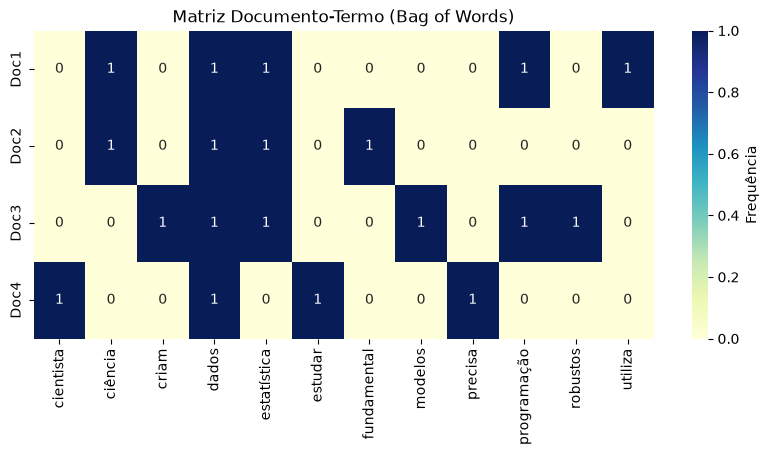

In [60]:
# Apresentar um Heatmp
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.heatmap(X_freq.toarray(), cmap="YlGnBu", annot=True, fmt="d", cbar_kws={'label': 'Frequência'}, xticklabels=vocabulario, yticklabels=[f'Doc{i+1}' for i in range(len(corpus_tech))])
plt.title("Matriz Documento-Termo (Bag of Words)")
plt.show()

### N-Grams

In [61]:
def mostrar_ngrams(n_min, n_max, descricao):
    vec = CountVectorizer(ngram_range=(n_min, n_max), stop_words=list(stop_words_pt))
    X = vec.fit_transform(corpus_tech)
    vocab = vec.get_feature_names_out()

    print(f"\n--- {descricao} ---")
    print (f"{descricao}: {len(vocab)} n-grams")
    print(vocab[:10])  # Exibindo apenas os 10 primeiros n-grams para não poluir a saída

In [62]:
# Bigram
mostrar_ngrams(2, 2, "Bigram")


--- Bigram ---
Bigram: 14 n-grams
['cientista dados' 'ciência dados' 'criam modelos' 'dados precisa'
 'dados robustos' 'dados utiliza' 'estatística criam'
 'estatística fundamental' 'estatística programação' 'fundamental ciência']


In [63]:
# trigrams
mostrar_ngrams(3, 3, "Trigram")


--- Trigram ---
Trigram: 11 n-grams
['cientista dados precisa' 'ciência dados utiliza' 'criam modelos dados'
 'dados precisa estudar' 'dados utiliza estatística'
 'estatística criam modelos' 'estatística fundamental ciência'
 'fundamental ciência dados' 'modelos dados robustos'
 'programação estatística criam']


### Análise de Colocaões

In [ ]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

texto_colocacoes_tech = """
    A ciência de dados utiliza estatística e programação.
    A estatística é fundamental para a ciência de dados.
    Programação e estatística criam modelos de dados robustos.
    O cientista de dados precisa estudar muito.
    O mercado de ações é altamente volátil.
    Os carros autônomos são uma tendência da tecnologia e usam muita programação.
    A inteligência artificial usa muita matemática e estatística em seus algoritmos.
"""

tokens = nltk.word_tokenize(texto_colocacoes_tech.lower(), language='portuguese')
# Remover Stop Words e Pomtuação
tokens = [token for token in tokens if token.isalnum() and token.lower() not in stop_words_pt]

In [66]:
# Cinfigurar o Filter de Colocaão no NLTK
bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(tokens)

# Filtrar pares que aparecem pelo menos 2 vezes
finder.apply_freq_filter(2)

In [67]:
# Top 5 Frequência
top_5_bigrams = finder.nbest(bigram_measures.raw_freq, 5)
print(top_5_bigrams)

[('ciência', 'dados'), ('programação', 'estatística')]


In [68]:
# Top 5 por PMI (Pointwise Mutual Information)
top_5_bigrams = finder.nbest(bigram_measures.pmi, 5)
print(top_5_bigrams)

[('ciência', 'dados'), ('programação', 'estatística')]
